# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 5. Modelo Final
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Modelo 4 MLP (Multilayer Perceptron)

**MLP (Multilayer Perceptron)**

   Aunque no incorpora memoria ni convolución temporal, permite establecer una referencia sobre el desempeño que puede alcanzarse con una red densa estándar al usar la misma representación de entrada procesada (scaler + PCA).

## Librerías

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Flatten
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score
import datetime
import joblib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping

2025-10-26 22:33:23.297870: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-26 22:33:23.309247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761539603.321259  169782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761539603.325208  169782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761539603.335413  169782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Carga de Datos

In [2]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /mnt/c/Users/Raven/Desktop/ProyectoIntegrador/github/TC5035-PI-E51/Avance5/processed_data_pipeline 
VIDEOS DIRECTORY: /mnt/c/Users/Raven/Desktop/ProyectoIntegrador/github/TC5035-PI-E51/Avance5/data/videos


In [3]:
# --- Cargar los Datos Preprocesados ---
print("--- Cargando datos preprocesados ---")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, "X_test.npy"))
y_train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_test.csv"))
y_train_labels = y_train_df['class'].values
y_test_labels = y_test_df['class'].values

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}\n")

# --- Codificar las Etiquetas ---
print("\n--- Codificando las etiquetas ---")
encoder_path = os.path.join(PROCESSED_DATA_DIR, "label_encoder.joblib")
label_encoder = joblib.load(encoder_path)
y_train_encoded = label_encoder.transform(y_train_labels)
y_test_encoded = label_encoder.transform(y_test_labels)
num_classes = len(label_encoder.classes_)

# Dividimos los datos de entrenamiento para crear un conjunto de validación
# Usaremos el 15% de los datos de entrenamiento para validación
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(
    X_train, 
    y_train_encoded, 
    test_size=0.15, # 15% para validación
    random_state=42,
    stratify=y_train_encoded # Mantiene la proporción de clases
)

y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_val_categorical = to_categorical(y_val_encoded)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)
print(f"Número de clases únicas: {num_classes}")

--- Cargando datos preprocesados ---
Forma de X_train: (207, 150, 5)
Forma de X_test: (37, 150, 5)


--- Codificando las etiquetas ---
Número de clases únicas: 4


## Modelo 4 MLP (Multilayer Perceptron)

In [4]:
# --- Construir el Modelo ---
print("\n--- Construyendo la arquitectura del modelo MLP ---")
model = Sequential([
    Flatten(input_shape=(X_train.shape[1], X_train.shape[2])),
    GaussianNoise(0.1), 
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(y_train_categorical.shape[1], activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model.summary()


--- Construyendo la arquitectura del modelo MLP ---


/home/raven/miniconda3/envs/lsm/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1761539606.323587  169782 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21458 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 750)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 750)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        48,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,276 (196.39 KB)

 Trainable params: 50,276 (196.39 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train_categorical,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val_categorical),
    callbacks=[early_stopping], # ¡Importante!
    verbose=1
)

Epoch 1/100


I0000 00:00:1761539607.955271  169909 service.cc:152] XLA service 0x7f2444017280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761539607.955302  169909 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-10-26 22:33:27.973390: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761539608.075578  169909 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3125 - loss: 3.8995

I0000 00:00:1761539609.395412  169909 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - accuracy: 0.3429 - loss: 3.4491 - val_accuracy: 0.3438 - val_loss: 1.6696
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4114 - loss: 2.2534 - val_accuracy: 0.5312 - val_loss: 1.2621
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4114 - loss: 1.8129 - val_accuracy: 0.6562 - val_loss: 1.1208
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5029 - loss: 1.5933 - val_accuracy: 0.7188 - val_loss: 1.0816
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5257 - loss: 1.5100 - val_accuracy: 0.7500 - val_loss: 1.0552
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6057 - loss: 1.3395 - val_accuracy: 0.7812 - val_loss: 1.0172
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6514 - loss: 1.1643 - val_accuracy: 0.7812 - val_loss: 0.9836
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6057 - loss: 1.2479 - val_accuracy: 0.7812 - val_loss: 0.9687
Epo

## Resultado

In [6]:
# --- Evaluar y Visualizar los Resultados ---
print("\n--- Evaluando el modelo con métricas detalladas ---")

# Realizar predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
# Convertir las probabilidades a etiquetas de clase predichas (la de mayor probabilidad)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)


--- Evaluando el modelo con métricas detalladas ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step


In [7]:
# Generar y mostrar el Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
# Reporte: precisión, recall y f1-score para cada clase.
report = classification_report(y_test_encoded, y_pred_encoded, target_names=label_encoder.classes_)
print(report)

# Accuracy (Precisión Global)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"La precisión (accuracy) del modelo es: {accuracy:.2f}")

# Recall
recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El recall (weighted) del modelo es: {recall:.2f}")

# F1-score
f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El F1-score (weighted) del modelo es: {f1:.2f}")


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Abrir       1.00      0.89      0.94         9
       Avión       0.91      1.00      0.95        10
      Borrar       1.00      1.00      1.00        10
          Tu       1.00      1.00      1.00         8

    accuracy                           0.97        37
   macro avg       0.98      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37

La precisión (accuracy) del modelo es: 0.97
El recall (weighted) del modelo es: 0.97
El F1-score (weighted) del modelo es: 0.97



--- Matriz de Confusión ---


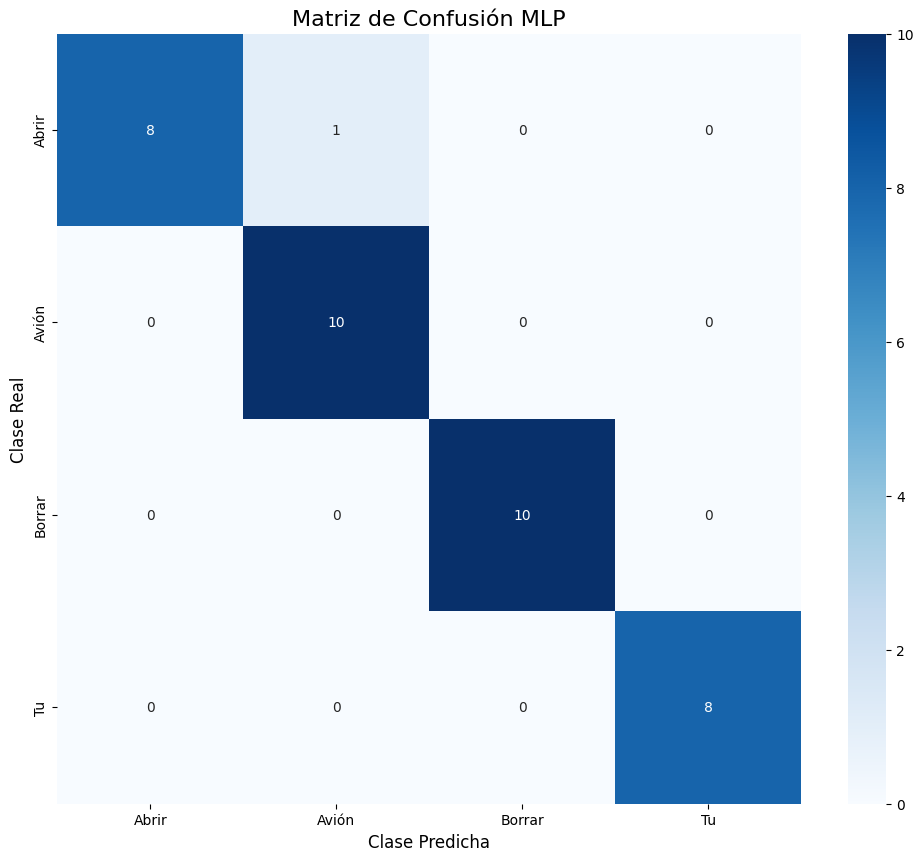

In [8]:
# Generar y mostrar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión MLP', fontsize=16)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.show()


--- Gráfica de precisión y pérdida durante el entrenamiento ---


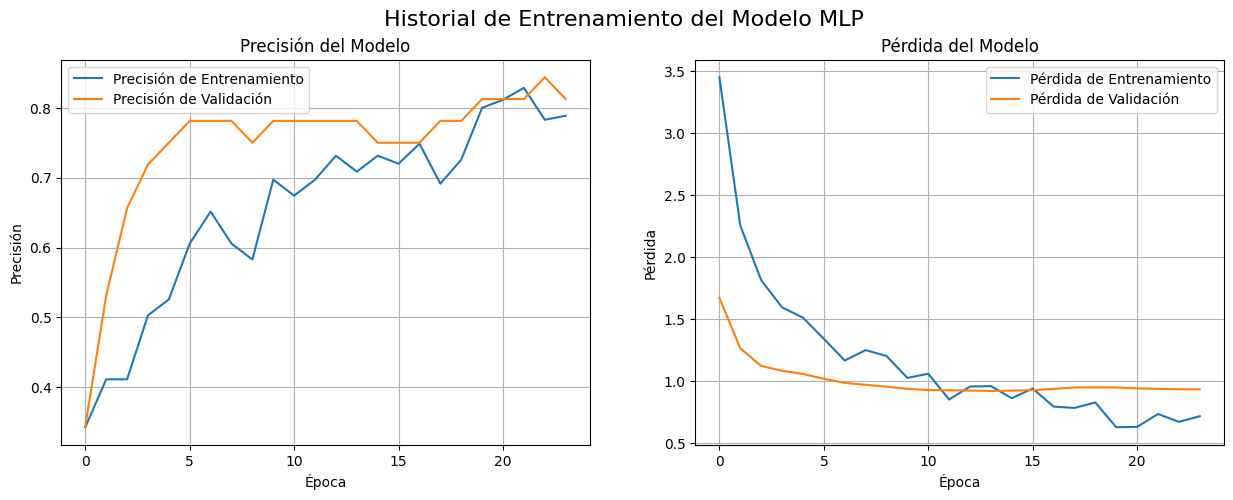


Entrenamiento completado!


In [9]:
# Graficar la precisión y la pérdida durante el entrenamiento
print("\n--- Gráfica de precisión y pérdida durante el entrenamiento ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Gráfica de Precisión
ax1.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Precisión de Validación')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)
# Gráfica de Pérdida
ax2.plot(history.history['loss'], label='Pérdida de Entrenamiento')
ax2.plot(history.history['val_loss'], label='Pérdida de Validación')
ax2.set_title('Pérdida del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)
plt.suptitle('Historial de Entrenamiento del Modelo MLP', fontsize=16)
plt.show()

print("\nEntrenamiento completado!")

## Análisis del Historial de Entrenamiento del Modelo MLP

La gráfica muestra el historial de precisión y pérdida del modelo MLP a lo largo del entrenamiento. Este análisis nos permite evaluar el aprendizaje del modelo, su capacidad de generalización y detectar posibles problemas como el sobreajuste (overfitting).

### 1. Gráfica de Precisión del Modelo (Izquierda)

* **Precisión de Entrenamiento (Línea Azul):** Comienza baja (aprox. 0.35) y muestra un comportamiento errático o "ruidoso" (con muchos picos y valles). Su tendencia general es ascendente, pero le cuesta converger y se mantiene por debajo de la precisión de validación durante casi todo el proceso.
* **Precisión de Validación (Línea Naranja):** Comienza al mismo nivel, pero asciende de forma mucho más rápida y estable, alcanzando un valor cercano a 0.78 alrededor de la época 5. A pesar de una ligera caída, se recupera y se estabiliza, terminando por encima de la precisión de entrenamiento.

**Interpretación Clave:** Es notable que la **precisión de validación sea consistentemente más alta que la de entrenamiento**. Esto no es un error; es un síntoma común de una **regularización fuerte**. Técnicas como `Dropout` y `L2` (usadas en el modelo del notebook) penalizan al modelo o "apagan" neuronas *solo* durante el entrenamiento. Esto hace que el entrenamiento sea más difícil (reduciendo su precisión), pero cuando el modelo se evalúa en el conjunto de validación (donde `Dropout` se desactiva), puede usar toda su capacidad aprendida, resultando en un mejor rendimiento.

### 2. Gráfica de Pérdida del Modelo (Derecha)

* **Pérdida de Entrenamiento (Línea Azul):** Comienza extremadamente alta (aprox. 3.5), lo cual es normal si la pérdida incluye los componentes de regularización L2. Cae drásticamente en las primeras 5 épocas y continúa descendiendo de forma más lenta pero inestable, terminando alrededor de 0.7.
* **Pérdida de Validación (Línea Naranja):** Comienza mucho más baja (aprox. 1.7), lo que confirma que la pérdida de entrenamiento está "inflada" por las penalizaciones de regularización. Desciende rápidamente y se estabiliza muy pronto, alrededor de la época 10, manteniéndose en un valor bajo y constante (aprox. 0.95).

**Interpretación Clave:** La pérdida de validación es el indicador más importante para la generalización. El hecho de que se estabilice y **no muestre una tendencia ascendente clara** es una excelente señal: **el modelo no está sobreajustando** (overfitting). La meseta indica que el modelo ha alcanzado su punto óptimo de generalización; entrenar más allá de este punto (como se ve en la pérdida de entrenamiento que sigue bajando) ya no mejora el rendimiento en datos nuevos.

### Conclusión

El modelo MLP muestra un **buen entrenamiento y una generalización robusta**. La presencia de `Dropout` y `L2` previene eficazmente el sobreajuste, como lo demuestra la curva de pérdida de validación plana y el hecho de que el rendimiento de validación supera al de entrenamiento.

In [10]:
MODELS_DIR = parent_dir / "models"
now = datetime.datetime.now()
timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
filename_h5 = f"model_4_mlp_{timestamp}.h5"
model.save(os.path.join(MODELS_DIR, filename_h5))


--- Generando Curvas ROC (One-vs-Rest) ---


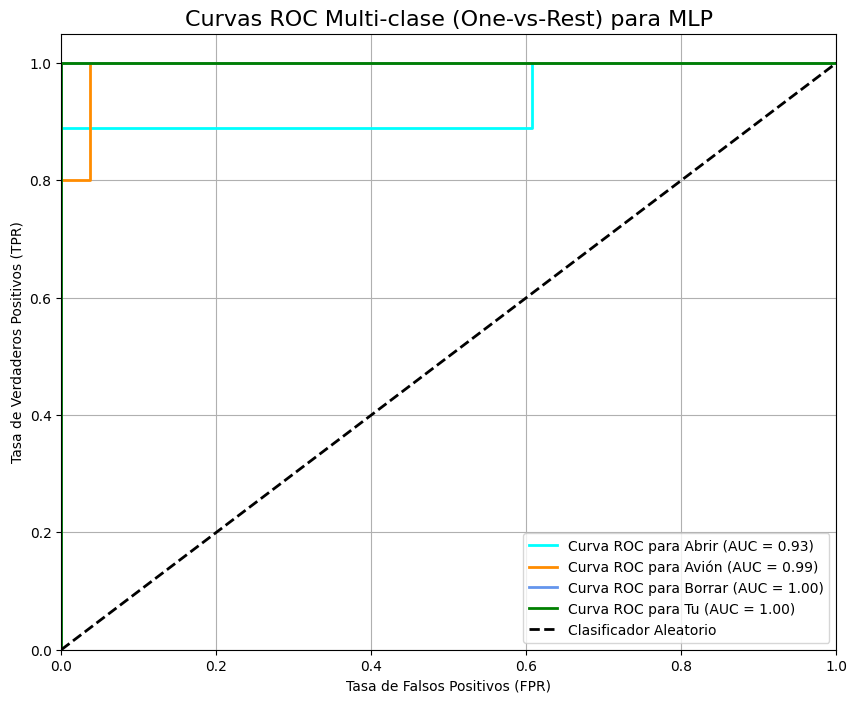

In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle

# --- 1. Curva ROC (Receiver Operating Characteristic) ---
print("\n--- Generando Curvas ROC (One-vs-Rest) ---")

# Configuración para la gráfica ROC
plt.figure(figsize=(10, 8))
lw = 2 # Ancho de línea
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
num_classes = y_train_categorical.shape[1]

# Calcular la curva ROC y el AUC para cada clase (One-vs-Rest)
for i, (color, class_name) in enumerate(zip(colors, label_encoder.classes_)):
    # y_test_categorical[:, i] -> etiquetas verdaderas para la clase i (0 o 1)
    # y_pred_probabilities[:, i] -> probabilidades predichas para la clase i
    fpr, tpr, _ = roc_curve(y_test_categorical[:, i], y_pred_probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=lw,
             label=f'Curva ROC para {class_name} (AUC = {roc_auc:0.2f})')

# Graficar la curva ROC "aleatoria" (baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=lw, label='Clasificador Aleatorio')

# Configuración final de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multi-clase (One-vs-Rest) para MLP', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("modelo4_roc_curve.png")
plt.show()

### Curva ROC

La curva ROC (Receiver Operating Characteristic) ilustra la capacidad del modelo para discriminar entre clases. Se grafica la Tasa de Verdaderos Positivos (TPR) contra la Tasa de Falsos Positivos (FPR) para cada clase (en un enfoque de "Uno contra el Resto" u OvR).

* **Área Bajo la Curva (AUC):** Es el valor numérico que resume el rendimiento. Un AUC de 1.0 es un clasificador perfecto, mientras que un AUC de 0.5 representa una adivinanza aleatoria (la línea punteada).
* **Análisis del Gráfico:** El gráfico generado muestra que todas las clases tienen un **AUC muy alto (cercano a 1.00)**. Las curvas están "pegadas" a la esquina superior izquierda, lo que demuestra una excelente capacidad de discriminación: el modelo alcanza una alta tasa de verdaderos positivos (detecta bien los gestos) con una tasa de falsos positivos muy baja (no se confunde al predecir un gesto cuando en realidad es otro). Esto refuerza el alto rendimiento general del 95% de accuracy.


--- Generando Curvas de Precisión-Recall (One-vs-Rest) ---


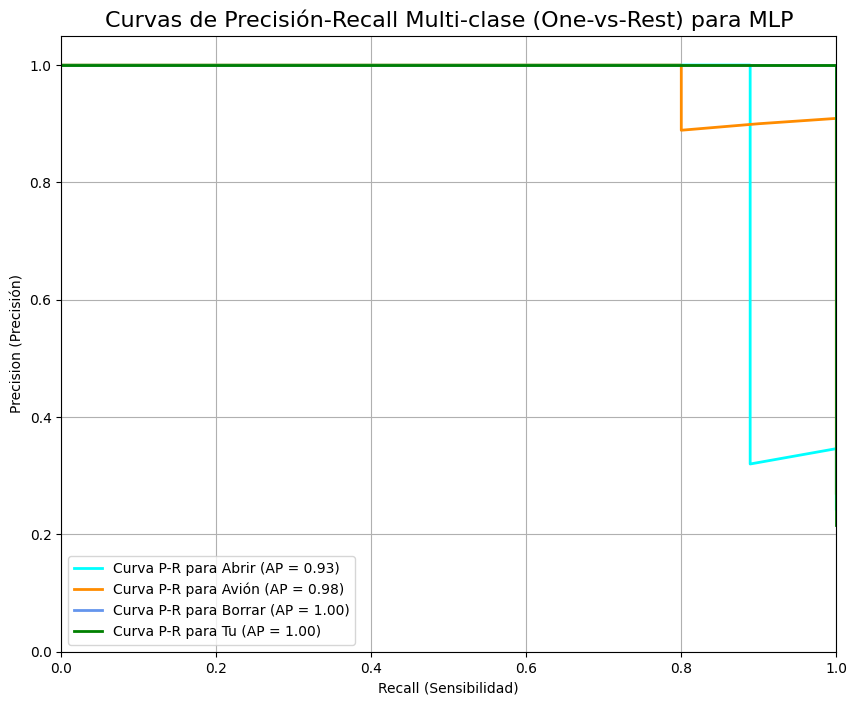

In [12]:
# --- 2. Curva de Precisión-Recall (Precision-Recall Curve) ---
print("\n--- Generando Curvas de Precisión-Recall (One-vs-Rest) ---")

# Configuración para la gráfica P-R
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])

# Calcular la curva P-R y el AP para cada clase (One-vs-Rest)
for i, (color, class_name) in enumerate(zip(colors, label_encoder.classes_)):
    precision, recall, _ = precision_recall_curve(y_test_categorical[:, i], y_pred_probabilities[:, i])
    avg_precision = average_precision_score(y_test_categorical[:, i], y_pred_probabilities[:, i])
    plt.plot(recall, precision, color=color, lw=lw,
             label=f'Curva P-R para {class_name} (AP = {avg_precision:0.2f})')

# Configuración final de la gráfica
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Precisión)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Curvas de Precisión-Recall Multi-clase (One-vs-Rest) para MLP', fontsize=16)
plt.legend(loc="best")
plt.grid(True)
plt.savefig("modelo4_pr_curve.png")
plt.show()

### Curva de Precisión-Recall

La curva de Precisión-Recall (P-R) muestra el balance entre la Precisión (Precisión) y el Recall (Sensibilidad) para diferentes umbrales. Es especialmente útil cuando hay desequilibrio de clases, pero también es una buena medida general del rendimiento.

* **Average Precision (AP):** Es el análogo del AUC para las curvas P-R, resumiendo el rendimiento de la curva. Un valor ideal es 1.0.
* **Análisis del Gráfico:** Al igual que las curvas ROC, los valores de **AP (Precisión Promedio) son muy altos (cercanos a 1.00)** para todas las clases. Las curvas se sitúan en la esquina superior derecha, indicando que el modelo puede alcanzar alta precisión y alto recall simultáneamente para todos los gestos. Esto confirma el excelente rendimiento reportado en la matriz de confusión y el reporte de clasificación (F1-score ponderado de 0.95).